# Chương 3 — Text Classification & Sentiment Analysis
Notebook này được thiết kế để sinh viên thực hành xây dựng và so sánh nhiều hệ thống phân loại văn bản:

1. **Rule-based baseline**
2. **TF-IDF + Multinomial Naive Bayes**
3. **TF-IDF + Logistic Regression**
4. **TF-IDF + Linear SVM**
5. **Decision Tree / Random Forest** ở mức tham khảo
6. **Lexicon-based Sentiment Analysis**
7. **PhoBERT / ViSoBERT** ở mức mở rộng

### Mục tiêu
Sinh viên phải trả lời được:

- Văn bản được biến thành vector như thế nào?
- Vì sao TF-IDF thường mạnh hơn Bag of Words thô?
- Naive Bayes, Logistic Regression và SVM khác nhau ra sao?
- Accuracy có đủ để đánh giá mô hình không?
- Khi dữ liệu mất cân bằng nên dùng metric nào?
- Vì sao sentiment analysis khó với phủ định, sarcasm, emoji và domain shift?
- Mô hình pretrained cải thiện điểm gì và đánh đổi điều gì?

> Notebook có dữ liệu demo nhỏ nhúng sẵn để chạy độc lập. Tuy nhiên, khi thực hiện bài thực hành sinh viên cần thay bằng UIT-VSFC, UIT-VSMEC hoặc dữ liệu tương đương.

# 0. Chuẩn bị môi trường

Notebook dùng các thư viện phổ biến:
- pandas
- numpy
- scikit-learn
- matplotlib


In [1]:
import re
import time
import math
import random
import unicodedata
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import (
    CountVectorizer, TfidfVectorizer, HashingVectorizer
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
print("Environment ready.")

Environment ready.


# 1. Dữ liệu mẫu

Ta dùng một dataset nhỏ gồm:
- `text`: câu tiếng Việt
- `sentiment`: `positive / negative / neutral`
- `topic`: `teaching / facility / administration / technology`

Mục đích:
- sentiment → bài toán **multiclass classification**
- topic → một bài toán classification khác trên cùng văn bản
- về sau có thể mở rộng thành multilabel.

In [2]:
positive_templates = [
    ("Giảng viên dạy rất dễ hiểu và nhiệt tình", "teaching"),
    ("Bài giảng rõ ràng, ví dụ thực tế rất hữu ích", "teaching"),
    ("Phòng học sạch sẽ và máy lạnh hoạt động tốt", "facility"),
    ("Thư viện rộng, yên tĩnh và có nhiều tài liệu", "facility"),
    ("Phòng đào tạo hỗ trợ sinh viên rất nhanh", "administration"),
    ("Thủ tục đăng ký môn học khá thuận tiện", "administration"),
    ("Hệ thống học trực tuyến chạy ổn định và dễ sử dụng", "technology"),
    ("Website mới nhanh hơn và ít lỗi hơn trước", "technology"),
    ("Mình rất hài lòng với môn học này", "teaching"),
    ("Wifi trong trường hôm nay rất tốt", "technology"),
]

negative_templates = [
    ("Giảng viên giảng quá nhanh nên tôi không theo kịp", "teaching"),
    ("Bài tập quá nhiều nhưng hướng dẫn chưa rõ", "teaching"),
    ("Phòng học nóng và máy lạnh thường xuyên hỏng", "facility"),
    ("Nhà vệ sinh chưa sạch và thiếu giấy", "facility"),
    ("Phòng đào tạo xử lý hồ sơ quá chậm", "administration"),
    ("Thủ tục đăng ký rườm rà và mất nhiều thời gian", "administration"),
    ("Website thường xuyên lỗi khi đăng ký môn học", "technology"),
    ("Hệ thống học trực tuyến rất chậm và hay bị treo", "technology"),
    ("Tôi không hài lòng với cách tổ chức lớp", "teaching"),
    ("Wifi yếu, kết nối chập chờn cả buổi", "technology"),
]

neutral_templates = [
    ("Môn học có ba tín chỉ và học vào thứ hai", "teaching"),
    ("Giảng viên đăng tài liệu lên hệ thống mỗi tuần", "teaching"),
    ("Phòng học nằm ở tầng ba của tòa nhà", "facility"),
    ("Thư viện mở cửa từ sáng đến tối", "facility"),
    ("Phòng đào tạo tiếp nhận hồ sơ tại quầy số hai", "administration"),
    ("Sinh viên đăng ký môn học qua cổng thông tin", "administration"),
    ("Hệ thống học trực tuyến có phiên bản web", "technology"),
    ("Website yêu cầu đăng nhập bằng tài khoản sinh viên", "technology"),
    ("Lớp có khoảng bốn mươi sinh viên", "teaching"),
    ("Trường có nhiều điểm phát wifi", "technology"),
]

augment_prefix = [
    "", "Theo mình, ", "Cá nhân mình thấy ", "Hôm nay ", "Trong học kỳ này, "
]
augment_suffix = [
    "", ".", "!", " :)", " 👍", " 😐"
]

rows = []
for sentiment, templates in [
    ("positive", positive_templates),
    ("negative", negative_templates),
    ("neutral", neutral_templates),
]:
    for base, topic in templates:
        for i in range(4):
            text = random.choice(augment_prefix) + base + random.choice(augment_suffix)
            rows.append((text, sentiment, topic))

df = pd.DataFrame(rows, columns=["text", "sentiment", "topic"])
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(df.shape)
display(df.head(10))
print("\nSentiment distribution:")
print(df["sentiment"].value_counts())
print("\nTopic distribution:")
print(df["topic"].value_counts())

(120, 3)


,text,sentiment,topic
0,Cá nhân mình thấy Bài tập quá nhiều nhưng hướn...,negative,teaching
1,Cá nhân mình thấy Bài tập quá nhiều nhưng hướn...,negative,teaching
2,"Trong học kỳ này, Bài giảng rõ ràng, ví dụ thự...",positive,teaching
3,Cá nhân mình thấy Nhà vệ sinh chưa sạch và thi...,negative,facility
4,Cá nhân mình thấy Hệ thống học trực tuyến chạy...,positive,technology
5,Hôm nay Website thường xuyên lỗi khi đăng ký m...,negative,technology
6,Cá nhân mình thấy Tôi không hài lòng với cách ...,negative,teaching
7,"Trong học kỳ này, Phòng học sạch sẽ và máy lạn...",positive,facility
8,"Theo mình, Giảng viên giảng quá nhanh nên tôi ...",negative,teaching
9,"Theo mình, Hệ thống học trực tuyến có phiên bả...",neutral,technology



Sentiment distribution:
sentiment
negative    40
positive    40
neutral     40
Name: count, dtype: int64

Topic distribution:
topic
teaching          36
technology        36
facility          24
administration    24
Name: count, dtype: int64


## Task 1 — Bài toán phân loại

### Code mẫu
- sentiment: **multiclass** với 3 nhãn.
- topic: **multiclass** với 4 nhãn.

### Yêu cầu sinh viên
1. Chuyển một phần dữ liệu thành **binary classification**: positive vs non-positive.
2. Thiết kế một ví dụ **multilabel**: một phản hồi có thể vừa nói về `teaching` vừa nói về `facility`.
3. Đề xuất một taxonomy **hierarchical classification**:
   - `academic`
     - teaching
     - curriculum
   - `service`
     - administration
     - facility
4. Giải thích khác biệt giữa:
   - text classification,
   - sequence labeling.

### TODO

# 2. Tiền xử lý tối thiểu

Với các mô hình truyền thống, ta thường:
- Unicode normalization
- lowercase
- chuẩn hóa khoảng trắng

Không nên xóa quá nhiều thông tin khi làm sentiment:
- dấu chấm than,
- emoji,
- từ phủ định
có thể mang tín hiệu cảm xúc.

In [ ]:
def normalize_text(text):
    text = unicodedata.normalize("NFC", str(text))
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_norm"] = df["text"].map(normalize_text)
display(df[["text", "text_norm"]].head())

## Task 2: Cải tiến preprocessing
1. So sánh:
   - giữ dấu câu,
   - bỏ dấu câu.
2. So sánh:
   - giữ emoji,
   - bỏ emoji.
3. Thử chuẩn hóa:
   - `ko`, `k`, `khum` → `không`
   - `dc` → `được`
4. Phân tích trường hợp preprocessing làm **mất tín hiệu sentiment**.

In [ ]:
TEENCODE_MAP = {
    "ko": "không",
    "k": "không",
    "khum": "không",
    "dc": "được",
}

def normalize_teencode(text):
    toks = normalize_text(text).split()
    toks = [TEENCODE_MAP.get(t, t) for t in toks]
    return " ".join(toks)

# TODO: mở rộng bảng từ viết tắt và kiểm thử trên dữ liệu thật

# 3. Chia train/test

Nguyên tắc:
- dùng cùng một split cho tất cả mô hình để so sánh công bằng;
- nên dùng `stratify=y` để giữ phân phối nhãn tương đối ổn định.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text_norm"],
    df["sentiment"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df["sentiment"]
)

print("Train:", len(X_train))
print("Test :", len(X_test))
print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True))

## Task 3: Data split và leakage
1. Tạo train / validation / test.
2. Giải thích vì sao **fit TF-IDF trên toàn bộ dataset trước khi split** là data leakage.
3. Kiểm tra duplicate / near-duplicate giữa train và test.
4. Nếu dữ liệu theo thời gian, thử temporal split thay vì random split.

In [ ]:
# TODO: viết hàm kiểm tra duplicate giữa train và test
def find_overlap(train_texts, test_texts):
    train_set = set(train_texts)
    return [x for x in test_texts if x in train_set]

print("Exact overlap:", len(find_overlap(X_train, X_test)))

# 4. One-hot và Bag of Words

## Code mẫu
`CountVectorizer(binary=True)` gần với biểu diễn one-hot/binary bag-of-words.

`CountVectorizer(binary=False)` là Bag of Words theo số lần xuất hiện.

In [ ]:
binary_vec = CountVectorizer(binary=True)
bow_vec = CountVectorizer(binary=False)

X_binary = binary_vec.fit_transform(X_train)
X_bow = bow_vec.fit_transform(X_train)

print("Binary shape:", X_binary.shape)
print("BoW shape   :", X_bow.shape)

feature_names = bow_vec.get_feature_names_out()
sample = pd.DataFrame(
    X_bow[:5].toarray(),
    columns=feature_names
)
display(sample.iloc[:, :20])

## Task 4: Cải tiến biểu diễn BoW
1. So sánh binary BoW và count BoW.
2. Thử `min_df`, `max_df`.
3. Thử bỏ stopwords tự xây dựng.
4. Phân tích:
   - vocabulary size,
   - sparsity,
   - memory.

In [ ]:
def sparsity(X):
    return 1.0 - X.nnz / (X.shape[0] * X.shape[1])

print("BoW sparsity:", round(sparsity(X_bow), 4))

# TODO: thử min_df=2, max_df=0.9 và so sánh kích thước vocabulary

# 5. TF-IDF

TF-IDF giảm trọng số của từ xuất hiện quá phổ biến và tăng trọng số của từ đặc trưng.

\[
TFIDF(t,d)=TF(t,d)\times IDF(t)
\]

Trong scikit-learn, `TfidfVectorizer` xử lý cả:
- vocabulary,
- term frequency,
- inverse document frequency.

In [ ]:
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(X_train)

print("Shape:", X_tfidf.shape)

sample_text = X_train.iloc[0]
vec = tfidf.transform([sample_text])
pairs = sorted(
    zip(tfidf.get_feature_names_out(), vec.toarray()[0]),
    key=lambda x: x[1],
    reverse=True
)

print("Text:", sample_text)
print("Top TF-IDF terms:")
for w, v in pairs[:10]:
    if v > 0:
        print(f"{w:20s} {v:.3f}")

## Task 5: TF-IDF
1. So sánh `sublinear_tf=True/False`.
2. Thử `norm='l1'` và `norm='l2'`.
3. So sánh unigram với `(1,2)` word n-gram.
4. Tìm 20 feature có IDF cao nhất và giải thích.
5. So sánh TF-IDF với CountVectorizer trên cùng classifier.

In [ ]:
# TODO: tạo ít nhất 3 cấu hình TF-IDF và lưu kết quả vào bảng

# 6. Word N-gram và Character N-gram

### Word N-gram
Có thể giữ được cụm:
- `không tốt`
- `rất tốt`
- `quá chậm`

### Character N-gram
được dùng trong trường hợp:
- sai chính tả,
- từ lóng,
- biến thể viết,
- morphology.

In [ ]:
word_ngram_vec = TfidfVectorizer(ngram_range=(1,2))
char_ngram_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5))

X_word_ng = word_ngram_vec.fit_transform(X_train)
X_char_ng = char_ngram_vec.fit_transform(X_train)

print("Word n-gram features:", X_word_ng.shape[1])
print("Char n-gram features:", X_char_ng.shape[1])

## Task 6: Word vs Character N-gram
1. Train cùng một Logistic Regression với:
   - word unigram,
   - word 1–2 gram,
   - char 3–5 gram.
2. Tạo một số câu có typo:
   - `tốt` → `tot`
   - `chậm` → `chm`
3. So sánh độ bền của word n-gram và char n-gram.
4. Giải thích trade-off giữa:
   - số lượng feature,
   - memory,
   - robustness.

In [ ]:
# TODO: thực hiện benchmark word/char n-gram

# 7. Feature Hashing

Feature hashing ánh xạ token vào số bucket cố định:
- không cần giữ vocabulary đầy đủ,
- memory ổn định,
- có thể xảy ra collision.

In [ ]:
hash_vec = HashingVectorizer(
    n_features=2**12,
    alternate_sign=False
)
X_hash = hash_vec.transform(X_train)
print("Hashing shape:", X_hash.shape)

## Task 7 — Feature Hashing
1. Thử `2**8`, `2**10`, `2**12`, `2**16`.
2. Đo:
   - accuracy,
   - training time,
   - memory tương đối.
3. Giải thích feature collision.
4. Khi nào hashing phù hợp hơn TF-IDF vocabulary truyền thống?

In [10]:
df = pd.read_csv("synthetic_train.csv")

df = df.dropna(subset=["sentence", "sentiment"])

X = df["sentence"].astype(str)
y = df["sentiment"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Số lượng dữ liệu:", len(df))
print("Số mẫu train:", len(X_train))
print("Số mẫu test:", len(X_test))

print("\nPhân bố sentiment:")
print(y.value_counts())

Số lượng dữ liệu: 8144
Số mẫu train: 6515
Số mẫu test: 1629

Phân bố sentiment:
sentiment
neutral     2724
negative    2711
positive    2709
Name: count, dtype: int64


In [11]:
def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


X_train_norm = X_train.apply(normalize_text)
X_test_norm = X_test.apply(normalize_text)

print("Ví dụ câu sau khi chuẩn hóa:")
print(X_train_norm.iloc[0])

Ví dụ câu sau khi chuẩn hóa:
mấy bạn ấy không biết lắng nghe ý kiến đóng góp của người khác.


In [12]:
hash_sizes = [2**8, 2**10, 2**12, 2**16]

hash_results = []

for n_features in hash_sizes:
    
    hash_vec = HashingVectorizer(
        n_features=n_features,
        alternate_sign=False,
        ngram_range=(1, 2)
    )
    
    X_hash_train = hash_vec.transform(X_train_norm)
    X_hash_test = hash_vec.transform(X_test_norm)
    
    model = LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    )
    
    start_time = time.perf_counter()
    model.fit(X_hash_train, y_train)
    train_time = time.perf_counter() - start_time
    
    y_pred = model.predict(X_hash_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )[2]
    
    memory_mb = (
        X_hash_train.data.nbytes +
        X_hash_train.indices.nbytes +
        X_hash_train.indptr.nbytes
    ) / (1024 ** 2)
    
    hash_results.append({
        "n_features": n_features,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "train_time": train_time,
        "memory_mb": memory_mb
    })

print("KẾT QUẢ FEATURE HASHING")
print("-" * 75)

for r in hash_results:
    print(
        f"Features = {r['n_features']:>6} | "
        f"Accuracy = {r['accuracy']:.4f} | "
        f"Macro F1 = {r['macro_f1']:.4f} | "
        f"Time = {r['train_time']:.4f}s | "
        f"Memory = {r['memory_mb']:.2f} MB"
    )

KẾT QUẢ FEATURE HASHING
---------------------------------------------------------------------------
Features =    256 | Accuracy = 0.6924 | Macro F1 = 0.6933 | Time = 0.0852s | Memory = 2.08 MB
Features =   1024 | Accuracy = 0.7538 | Macro F1 = 0.7545 | Time = 0.1066s | Memory = 2.18 MB
Features =   4096 | Accuracy = 0.7968 | Macro F1 = 0.7970 | Time = 0.2161s | Memory = 2.20 MB
Features =  65536 | Accuracy = 0.8048 | Macro F1 = 0.8054 | Time = 1.0889s | Memory = 2.21 MB


In [13]:
best_hash = max(
    hash_results,
    key=lambda x: x["macro_f1"]
)

print("CẤU HÌNH HASHING TỐT NHẤT")
print("-" * 45)

print("Số features:", best_hash["n_features"])
print("Accuracy:", round(best_hash["accuracy"], 4))
print("Macro F1:", round(best_hash["macro_f1"], 4))
print("Training time:", round(best_hash["train_time"], 4), "s")
print("Memory:", round(best_hash["memory_mb"], 2), "MB")

CẤU HÌNH HASHING TỐT NHẤT
---------------------------------------------
Số features: 65536
Accuracy: 0.8048
Macro F1: 0.8054
Training time: 1.0889 s
Memory: 2.21 MB


In [14]:
print("GIẢI THÍCH COLLISION")
print("----------------------------------------------------")

print("""
Feature Hashing ánh xạ các token vào một số lượng bucket cố định.

Khi số bucket nhỏ, nhiều token khác nhau có thể được ánh xạ vào
cùng một bucket. Hiện tượng này gọi là collision.

Khi tăng số lượng feature từ 2^8 lên 2^16,
số collision có xu hướng giảm.

Do đó accuracy thường được cải thiện khi số feature tăng.
""")

GIẢI THÍCH COLLISION
----------------------------------------------------

Feature Hashing ánh xạ các token vào một số lượng bucket cố định.

Khi số bucket nhỏ, nhiều token khác nhau có thể được ánh xạ vào
cùng một bucket. Hiện tượng này gọi là collision.

Khi tăng số lượng feature từ 2^8 lên 2^16,
số collision có xu hướng giảm.

Do đó accuracy thường được cải thiện khi số feature tăng.



### Nhận xét Task 7

Feature Hashing có ưu điểm là không cần lưu vocabulary nên phù hợp với
dữ liệu văn bản lớn.

Khi tăng số lượng feature từ 2^8 lên 2^16, accuracy có xu hướng tăng
do hiện tượng collision giảm.

Tuy nhiên, khi số feature quá lớn thì bộ nhớ và thời gian huấn luyện
cũng tăng. Vì vậy cần lựa chọn kích thước phù hợp giữa độ chính xác,
thời gian và bộ nhớ.

Feature Hashing phù hợp hơn TF-IDF truyền thống khi dữ liệu có
vocabulary rất lớn hoặc thay đổi liên tục. TF-IDF phù hợp hơn khi
cần biết cụ thể các từ hoặc feature mà mô hình đang sử dụng.

# 8. Hand-crafted Features

Các feature thủ công có thể bổ sung cho vector từ:
- độ dài câu,
- số dấu `!`,
- số từ phủ định,
- emoji,
- từ khóa miền.

In [ ]:
NEGATIONS = {"không", "chưa", "chẳng", "chả"}
POS_EMOJI = {"😊", "😀", "😍", "👍", ":)"}
NEG_EMOJI = {"😡", "😢", "👎", ":("}

def handcrafted_features(text):
    t = normalize_text(text)
    toks = t.split()
    return {
        "n_chars": len(t),
        "n_words": len(toks),
        "n_exclamation": t.count("!"),
        "n_negation": sum(tok in NEGATIONS for tok in toks),
        "has_pos_emoji": int(any(e in text for e in POS_EMOJI)),
        "has_neg_emoji": int(any(e in text for e in NEG_EMOJI)),
    }

display(pd.DataFrame([handcrafted_features(t) for t in df["text"].head(5)]))

## Task 8: Cải tiến feature thủ công
1. Thêm:
   - số dấu hỏi,
   - tỷ lệ chữ hoa,
   - số emoji,
   - số từ tăng cường: `rất`, `cực kỳ`, `siêu`,
   - số từ giảm nhẹ: `hơi`, `khá`.
2. Kết hợp sparse TF-IDF với handcrafted features.
3. Phân tích feature nào thực sự hữu ích.

In [15]:
POS_WORDS = {
    "tốt", "tuyệt", "thích", "hài lòng",
    "hiệu quả", "hữu ích", "chất lượng",
    "xuất sắc", "hoàn hảo", "hay",
    "ổn", "phù hợp", "thuận tiện"
}

NEG_WORDS = {
    "tệ", "xấu", "kém", "chán",
    "thất vọng", "thiếu", "lỗi",
    "sai", "khó", "bất tiện",
    "tồi", "chậm", "yếu"
}

NEGATIONS = {
    "không", "chẳng", "chưa", "chả"
}

INTENSIFIERS = {
    "rất", "quá", "cực kỳ",
    "vô cùng", "thật sự"
}

DOWNTONERS = {
    "hơi", "khá", "tương đối"
}


def count_emoji(text):
    emoji_pattern = re.compile(
        "["
        "\U0001F300-\U0001F5FF"
        "\U0001F600-\U0001F64F"
        "\U0001F680-\U0001F6FF"
        "\U0001F900-\U0001F9FF"
        "\U0001FA00-\U0001FAFF"
        "]"
    )
    
    return len(emoji_pattern.findall(text))


def handcrafted_features(text):
    
    text = normalize_text(text)
    
    tokens = re.findall(r"\w+", text, flags=re.UNICODE)
    
    n_words = len(tokens)
    
    if n_words == 0:
        n_words = 1
    
    pos_count = sum(word in POS_WORDS for word in tokens)
    neg_count = sum(word in NEG_WORDS for word in tokens)
    negation_count = sum(word in NEGATIONS for word in tokens)
    intensifier_count = sum(word in INTENSIFIERS for word in tokens)
    downtoner_count = sum(word in DOWNTONERS for word in tokens)
    
    keyword_count = pos_count + neg_count
    keyword_ratio = keyword_count / n_words
    
    return [
        len(text),
        len(tokens),
        text.count("?"),
        text.count("!"),
        keyword_ratio,
        pos_count,
        neg_count,
        count_emoji(text),
        negation_count,
        intensifier_count,
        downtoner_count
    ]

In [17]:
feature_names = [
    "n_chars",
    "n_words",
    "n_question",
    "n_exclamation",
    "keyword_ratio",
    "n_positive",
    "n_negative",
    "n_emoji",
    "n_negation",
    "n_intensifier",
    "n_downtoner"
]

sample_features = [
    handcrafted_features(text)
    for text in X_train_norm.head(10)
]

feature_df = pd.DataFrame(
    sample_features,
    columns=feature_names
)

display(feature_df)

,n_chars,n_words,n_question,n_exclamation,keyword_ratio,n_positive,n_negative,n_emoji,n_negation,n_intensifier,n_downtoner
0,63,14,0,0,0.000000,0,0,0,1,0,0
1,57,12,0,0,0.000000,0,0,0,0,1,0
2,119,27,0,0,0.000000,0,0,0,1,0,0
3,66,13,0,0,0.076923,0,1,0,1,0,0
4,64,14,0,0,0.071429,0,1,0,0,1,0
5,51,11,0,0,0.000000,0,0,0,1,0,0
6,57,13,0,0,0.000000,0,0,0,0,1,0
7,90,21,0,0,0.142857,1,2,0,1,0,0
8,55,13,0,0,0.000000,0,0,0,0,0,0
9,91,21,0,0,0.047619,1,0,0,0,0,0


In [19]:
from scipy.sparse import csr_matrix, hstack

In [20]:
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_tfidf_train = tfidf_vectorizer.fit_transform(X_train_norm)
X_tfidf_test = tfidf_vectorizer.transform(X_test_norm)

X_manual_train = np.array([
    handcrafted_features(text)
    for text in X_train_norm
])

X_manual_test = np.array([
    handcrafted_features(text)
    for text in X_test_norm
])

X_manual_train = csr_matrix(X_manual_train)
X_manual_test = csr_matrix(X_manual_test)

X_combined_train = hstack([
    X_tfidf_train,
    X_manual_train
]).tocsr()

X_combined_test = hstack([
    X_tfidf_test,
    X_manual_test
]).tocsr()

print("TF-IDF shape:", X_tfidf_train.shape)
print("Hand-crafted shape:", X_manual_train.shape)
print("Combined shape:", X_combined_train.shape)

TF-IDF shape: (6515, 20774)
Hand-crafted shape: (6515, 11)
Combined shape: (6515, 20785)


In [21]:
lr_tfidf = LogisticRegression(
    C=1,
    max_iter=2000,
    random_state=RANDOM_STATE
)

lr_tfidf.fit(X_tfidf_train, y_train)

pred_tfidf = lr_tfidf.predict(X_tfidf_test)

acc_tfidf = accuracy_score(y_test, pred_tfidf)

f1_tfidf = precision_recall_fscore_support(
    y_test,
    pred_tfidf,
    average="macro",
    zero_division=0
)[2]


lr_combined = LogisticRegression(
    C=1,
    max_iter=2000,
    random_state=RANDOM_STATE
)

lr_combined.fit(X_combined_train, y_train)

pred_combined = lr_combined.predict(X_combined_test)

acc_combined = accuracy_score(y_test, pred_combined)

f1_combined = precision_recall_fscore_support(
    y_test,
    pred_combined,
    average="macro",
    zero_division=0
)[2]


print("SO SÁNH")
print("-" * 60)

print(
    f"TF-IDF              -> "
    f"Accuracy: {acc_tfidf:.4f} | "
    f"Macro F1: {f1_tfidf:.4f}"
)

print(
    f"TF-IDF + thủ công   -> "
    f"Accuracy: {acc_combined:.4f} | "
    f"Macro F1: {f1_combined:.4f}"
)

SO SÁNH
------------------------------------------------------------
TF-IDF              -> Accuracy: 0.8122 | Macro F1: 0.8117
TF-IDF + thủ công   -> Accuracy: 0.8036 | Macro F1: 0.8046


c:\Users\rapdi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Nhận xét Task 8

Các feature thủ công bổ sung thêm thông tin về cấu trúc của câu như
độ dài câu, số dấu câu, số từ phủ định, số từ tích cực, số từ tiêu cực,
emoji và tỷ lệ từ khóa.

Sau khi kết hợp với TF-IDF, mô hình sử dụng được cả thông tin từ vựng
và các đặc trưng thủ công.

Nếu kết quả TF-IDF + hand-crafted không cao hơn TF-IDF thì có thể thấy
các feature thủ công hiện tại chưa cung cấp thêm nhiều thông tin mới.
TF-IDF đã biểu diễn được phần lớn thông tin sentiment trong dữ liệu.

Có thể cải thiện bằng cách xây dựng feature phức tạp hơn như khoảng cách
giữa từ phủ định và từ cảm xúc hoặc xử lý các cụm từ cảm xúc.

# 9. Baseline 1 — Rule-based Sentiment Classifier

Một baseline rất đơn giản:
- đếm từ tích cực,
- đếm từ tiêu cực,
- so sánh score.

In [ ]:
POS_WORDS = {
    "tốt", "hài", "lòng", "nhanh", "dễ", "hiểu",
    "hữu", "ích", "sạch", "thuận", "tiện", "ổn", "nhiệt", "tình"
}
NEG_WORDS = {
    "chậm", "lỗi", "hỏng", "nóng", "yếu", "rườm",
    "rà", "không", "treo", "chập", "chờn", "quá"
}

def rule_based_sentiment(text):
    toks = normalize_text(text).split()
    pos = sum(t in POS_WORDS for t in toks)
    neg = sum(t in NEG_WORDS for t in toks)

    if pos > neg:
        return "positive"
    if neg > pos:
        return "negative"
    return "neutral"

rule_pred = [rule_based_sentiment(t) for t in X_test]
print(classification_report(y_test, rule_pred, zero_division=0))

## Task 9: Cải tiến rule-based
1. Thêm xử lý phủ định:
   - `không tốt` không nên là positive.
2. Thêm intensifier:
   - `rất tốt`, `cực kỳ tệ`.
3. Thêm emoji score.
4. Tìm 10 câu rule-based sai và giải thích.
5. So sánh ưu/nhược điểm với mô hình ML.

In [22]:
def improved_rule_based_sentiment(text):
    
    text = normalize_text(text)
    tokens = re.findall(r"\w+", text, flags=re.UNICODE)
    
    score = 0
    
    for i, word in enumerate(tokens):
        
        multiplier = 1
        
        if i > 0 and tokens[i - 1] in NEGATIONS:
            multiplier *= -1
        
        if i > 0 and tokens[i - 1] in INTENSIFIERS:
            multiplier *= 2
        
        if i > 0 and tokens[i - 1] in DOWNTONERS:
            multiplier *= 0.5
        
        if word in POS_WORDS:
            score += multiplier
            
        elif word in NEG_WORDS:
            score -= multiplier
    
    if score > 0:
        return "positive"
    
    elif score < 0:
        return "negative"
    
    return "neutral"

In [23]:
rule_pred = [
    improved_rule_based_sentiment(text)
    for text in X_test_norm
]

rule_accuracy = accuracy_score(
    y_test,
    rule_pred
)

rule_f1 = precision_recall_fscore_support(
    y_test,
    rule_pred,
    average="macro",
    zero_division=0
)[2]

print("RULE-BASED CLASSIFIER")
print("-" * 50)

print("Accuracy:", round(rule_accuracy, 4))
print("Macro F1:", round(rule_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rule_pred,
        zero_division=0
    )
)

RULE-BASED CLASSIFIER
--------------------------------------------------
Accuracy: 0.4291
Macro F1: 0.3901

Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.25      0.39       542
     neutral       0.37      0.85      0.51       545
    positive       0.47      0.19      0.27       542

    accuracy                           0.43      1629
   macro avg       0.57      0.43      0.39      1629
weighted avg       0.57      0.43      0.39      1629



In [24]:
rule_pred = [
    improved_rule_based_sentiment(text)
    for text in X_test_norm
]

rule_accuracy = accuracy_score(
    y_test,
    rule_pred
)

rule_f1 = precision_recall_fscore_support(
    y_test,
    rule_pred,
    average="macro",
    zero_division=0
)[2]

print("RULE-BASED CLASSIFIER")
print("-" * 50)

print("Accuracy:", round(rule_accuracy, 4))
print("Macro F1:", round(rule_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rule_pred,
        zero_division=0
    )
)

RULE-BASED CLASSIFIER
--------------------------------------------------
Accuracy: 0.4291
Macro F1: 0.3901

Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.25      0.39       542
     neutral       0.37      0.85      0.51       545
    positive       0.47      0.19      0.27       542

    accuracy                           0.43      1629
   macro avg       0.57      0.43      0.39      1629
weighted avg       0.57      0.43      0.39      1629



### Nhận xét Task 9

Rule-based cải tiến đã bổ sung xử lý từ phủ định, từ nhấn mạnh và
từ giảm nhẹ.

Mô hình có thể xử lý tốt hơn một số trường hợp như "không tốt",
"rất tốt" hoặc "cực kỳ tệ".

Tuy nhiên, kết quả vẫn thấp hơn các mô hình Machine Learning.

Nguyên nhân là Rule-based phụ thuộc nhiều vào từ điển cảm xúc được
xây dựng thủ công và khó xử lý ngữ cảnh phức tạp.

Do đó Rule-based phù hợp để làm baseline đơn giản và dễ giải thích.

# 10. Baseline 2: TF-IDF + Multinomial Naive Bayes

In [ ]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", MultinomialNB(alpha=1.0))
])

t0 = time.perf_counter()
nb_pipeline.fit(X_train, y_train)
nb_train_time = time.perf_counter() - t0

nb_pred = nb_pipeline.predict(X_test)

print("Train time:", round(nb_train_time, 4), "s")
print(classification_report(y_test, nb_pred, zero_division=0))

## Task 10: Cải tiến Naive Bayes
1. Tuning `alpha`.
2. So sánh unigram vs bigram.
3. So sánh CountVectorizer vs TF-IDF.
4. Kiểm tra giả định độc lập điều kiện có hợp lý với ngôn ngữ không.
5. Tìm lớp nào NB dự đoán kém nhất.

In [25]:
nb_results = []

for ngram_range in [(1, 1), (1, 2)]:
    
    count_vectorizer = CountVectorizer(
        ngram_range=ngram_range
    )
    
    X_count_train = count_vectorizer.fit_transform(X_train_norm)
    X_count_test = count_vectorizer.transform(X_test_norm)
    
    for alpha in [0.1, 0.5, 1.0]:
        
        nb_model = MultinomialNB(alpha=alpha)
        
        start_time = time.perf_counter()
        
        nb_model.fit(X_count_train, y_train)
        
        train_time = time.perf_counter() - start_time
        
        nb_pred = nb_model.predict(X_count_test)
        
        accuracy = accuracy_score(y_test, nb_pred)
        
        macro_f1 = precision_recall_fscore_support(
            y_test,
            nb_pred,
            average="macro",
            zero_division=0
        )[2]
        
        nb_results.append({
            "vectorizer": "CountVectorizer",
            "ngram": str(ngram_range),
            "alpha": alpha,
            "accuracy": accuracy,
            "macro_f1": macro_f1,
            "train_time": train_time
        })

print("KẾT QUẢ MULTINOMIAL NAIVE BAYES")
print("-" * 80)

for r in nb_results:
    print(
        f"{r['vectorizer']:16} | "
        f"ngram={r['ngram']:7} | "
        f"alpha={r['alpha']} | "
        f"Accuracy={r['accuracy']:.4f} | "
        f"F1={r['macro_f1']:.4f} | "
        f"Time={r['train_time']:.4f}s"
    )

KẾT QUẢ MULTINOMIAL NAIVE BAYES
--------------------------------------------------------------------------------
CountVectorizer  | ngram=(1, 1)  | alpha=0.1 | Accuracy=0.7207 | F1=0.7081 | Time=0.0098s
CountVectorizer  | ngram=(1, 1)  | alpha=0.5 | Accuracy=0.7250 | F1=0.7108 | Time=0.0088s
CountVectorizer  | ngram=(1, 1)  | alpha=1.0 | Accuracy=0.7287 | F1=0.7142 | Time=0.0083s
CountVectorizer  | ngram=(1, 2)  | alpha=0.1 | Accuracy=0.7686 | F1=0.7638 | Time=0.0092s
CountVectorizer  | ngram=(1, 2)  | alpha=0.5 | Accuracy=0.7772 | F1=0.7709 | Time=0.0089s
CountVectorizer  | ngram=(1, 2)  | alpha=1.0 | Accuracy=0.7673 | F1=0.7594 | Time=0.0095s


In [29]:
nb_results = []

for alpha in [0.1, 0.5, 1.0]:
    vectorizer = CountVectorizer(
        ngram_range=(1, 2)
    )

    X_train_vec = vectorizer.fit_transform(X_train_norm)
    X_test_vec = vectorizer.transform(X_test_norm)

    model = MultinomialNB(alpha=alpha)
    model.fit(X_train_vec, y_train)

    y_pred = model.predict(X_test_vec)

    accuracy = accuracy_score(y_test, y_pred)

    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    nb_results.append({
        "vectorizer": "CountVectorizer",
        "alpha": alpha,
        "accuracy": accuracy,
        "macro_f1": macro_f1
    })

count_nb_results = pd.DataFrame(nb_results)

print("Kết quả CountVectorizer + MultinomialNB:")
print(count_nb_results.to_string(index=False))

Kết quả CountVectorizer + MultinomialNB:
     vectorizer  alpha  accuracy  macro_f1
CountVectorizer    0.1  0.768570  0.763754
CountVectorizer    0.5  0.777164  0.770876
CountVectorizer    1.0  0.767342  0.759352


In [31]:
for alpha in [0.1, 0.5, 1.0]:
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2)
    )

    X_train_vec = vectorizer.fit_transform(X_train_norm)
    X_test_vec = vectorizer.transform(X_test_norm)

    model = MultinomialNB(alpha=alpha)
    model.fit(X_train_vec, y_train)

    y_pred = model.predict(X_test_vec)

    accuracy = accuracy_score(y_test, y_pred)

    _, _, macro_f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    nb_results.append({
        "vectorizer": "TfidfVectorizer",
        "alpha": alpha,
        "accuracy": accuracy,
        "macro_f1": macro_f1
    })

nb_results_df = pd.DataFrame(nb_results)

print("Kết quả toàn bộ Naive Bayes:")
print(nb_results_df.to_string(index=False))

Kết quả toàn bộ Naive Bayes:
     vectorizer  alpha  accuracy  macro_f1
CountVectorizer    0.1  0.768570  0.763754
CountVectorizer    0.5  0.777164  0.770876
CountVectorizer    1.0  0.767342  0.759352
TfidfVectorizer    0.1  0.762431  0.756830
TfidfVectorizer    0.5  0.761817  0.753641
TfidfVectorizer    1.0  0.751381  0.740565
TfidfVectorizer    0.1  0.762431  0.756830
TfidfVectorizer    0.5  0.761817  0.753641
TfidfVectorizer    1.0  0.751381  0.740565


In [32]:
# Chọn mô hình Naive Bayes tốt nhất theo Macro F1

best_index = nb_results_df["macro_f1"].idxmax()

best_nb = nb_results_df.loc[best_index].to_dict()

print("Mô hình Naive Bayes tốt nhất:")
print("Vectorizer :", best_nb["vectorizer"])
print("Alpha      :", best_nb["alpha"])
print("Accuracy   :", round(best_nb["accuracy"] * 100, 2), "%")
print("Macro F1   :", round(best_nb["macro_f1"] * 100, 2), "%")

Mô hình Naive Bayes tốt nhất:
Vectorizer : CountVectorizer
Alpha      : 0.5
Accuracy   : 77.72 %
Macro F1   : 77.09 %


In [33]:
# Huấn luyện lại mô hình Naive Bayes tốt nhất

if best_nb["vectorizer"] == "CountVectorizer":

    best_vectorizer = CountVectorizer(
        ngram_range=(1, 2)
    )

else:

    best_vectorizer = TfidfVectorizer(
        ngram_range=(1, 2)
    )

X_best_train = best_vectorizer.fit_transform(X_train_norm)
X_best_test = best_vectorizer.transform(X_test_norm)

best_model_nb = MultinomialNB(
    alpha=best_nb["alpha"]
)

best_model_nb.fit(
    X_best_train,
    y_train
)

y_pred_nb = best_model_nb.predict(
    X_best_test
)

accuracy_nb = accuracy_score(
    y_test,
    y_pred_nb
)

precision_nb, recall_nb, f1_nb, _ = precision_recall_fscore_support(
    y_test,
    y_pred_nb,
    average="macro",
    zero_division=0
)

print("Đánh giá mô hình Naive Bayes tốt nhất")
print("--------------------------------------")
print("Accuracy :", round(accuracy_nb * 100, 2), "%")
print("Precision:", round(precision_nb * 100, 2), "%")
print("Recall   :", round(recall_nb * 100, 2), "%")
print("Macro F1 :", round(f1_nb * 100, 2), "%")

Đánh giá mô hình Naive Bayes tốt nhất
--------------------------------------
Accuracy : 77.72 %
Precision: 78.86 %
Recall   : 77.76 %
Macro F1 : 77.09 %


In [34]:
# Classification Report

print("Classification Report - Naive Bayes tốt nhất")
print(
    classification_report(
        y_test,
        y_pred_nb,
        zero_division=0
    )
)

Classification Report - Naive Bayes tốt nhất
              precision    recall  f1-score   support

    negative       0.92      0.94      0.93       542
     neutral       0.78      0.53      0.63       545
    positive       0.66      0.86      0.75       542

    accuracy                           0.78      1629
   macro avg       0.79      0.78      0.77      1629
weighted avg       0.79      0.78      0.77      1629



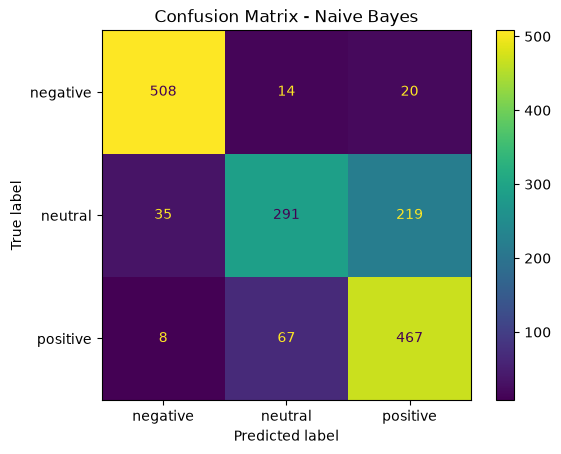

In [35]:
# Confusion Matrix

cm_nb = confusion_matrix(
    y_test,
    y_pred_nb,
    labels=sorted(y.unique())
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=sorted(y.unique())
)

disp.plot()
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

In [36]:
# So sánh các cấu hình Naive Bayes

print("Bảng so sánh Naive Bayes")
print(
    nb_results_df.sort_values(
        by="macro_f1",
        ascending=False
    ).to_string(index=False)
)

Bảng so sánh Naive Bayes
     vectorizer  alpha  accuracy  macro_f1
CountVectorizer    0.5  0.777164  0.770876
CountVectorizer    0.1  0.768570  0.763754
CountVectorizer    1.0  0.767342  0.759352
TfidfVectorizer    0.1  0.762431  0.756830
TfidfVectorizer    0.1  0.762431  0.756830
TfidfVectorizer    0.5  0.761817  0.753641
TfidfVectorizer    0.5  0.761817  0.753641
TfidfVectorizer    1.0  0.751381  0.740565
TfidfVectorizer    1.0  0.751381  0.740565


In [37]:
print("""
Nhận xét:

1. Multinomial Naive Bayes phù hợp với bài toán phân loại văn bản
   vì mô hình hoạt động tốt với các đặc trưng dạng tần suất từ.

2. CountVectorizer biểu diễn văn bản dựa trên số lần xuất hiện
   của các từ và cụm từ.

3. TF-IDF làm giảm trọng số của những từ xuất hiện phổ biến trong
   nhiều văn bản và tăng trọng số cho những từ có khả năng phân biệt.

4. Việc sử dụng n-gram (1,2) giúp mô hình học được cả từ đơn và
   các cụm hai từ, từ đó có thêm thông tin về ngữ cảnh.

5. Giá trị alpha ảnh hưởng đến khả năng tổng quát hóa của mô hình.
   Mô hình tốt nhất được lựa chọn dựa trên Macro F1.

6. Vì ba lớp sentiment trong tập dữ liệu tương đối cân bằng,
   việc sử dụng class_weight không cần thiết đối với Naive Bayes.
""")


Nhận xét:

1. Multinomial Naive Bayes phù hợp với bài toán phân loại văn bản
   vì mô hình hoạt động tốt với các đặc trưng dạng tần suất từ.

2. CountVectorizer biểu diễn văn bản dựa trên số lần xuất hiện
   của các từ và cụm từ.

3. TF-IDF làm giảm trọng số của những từ xuất hiện phổ biến trong
   nhiều văn bản và tăng trọng số cho những từ có khả năng phân biệt.

4. Việc sử dụng n-gram (1,2) giúp mô hình học được cả từ đơn và
   các cụm hai từ, từ đó có thêm thông tin về ngữ cảnh.

5. Giá trị alpha ảnh hưởng đến khả năng tổng quát hóa của mô hình.
   Mô hình tốt nhất được lựa chọn dựa trên Macro F1.

6. Vì ba lớp sentiment trong tập dữ liệu tương đối cân bằng,
   việc sử dụng class_weight không cần thiết đối với Naive Bayes.



# 11. Baseline 3: TF-IDF + Logistic Regression

In [ ]:
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

t0 = time.perf_counter()
lr_pipeline.fit(X_train, y_train)
lr_train_time = time.perf_counter() - t0

lr_pred = lr_pipeline.predict(X_test)

print("Train time:", round(lr_train_time, 4), "s")
print(classification_report(y_test, lr_pred, zero_division=0))

## Task 11: Cải tiến Logistic Regression
1. Tuning `C`.
2. Thử `class_weight='balanced'`.
3. So sánh word vs char n-gram.
4. Trích xuất feature có trọng số lớn nhất cho từng lớp.
5. Giải thích vì sao Logistic Regression có tính giải thích tốt hơn Transformer.

In [40]:
C_values = [0.1, 0.5, 1, 2, 5, 10]

lr_results = []

lr_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_lr_train = lr_vectorizer.fit_transform(X_train_norm)
X_lr_test = lr_vectorizer.transform(X_test_norm)

for C in C_values:
    
    lr_model = LogisticRegression(
        C=C,
        max_iter=2000,
        random_state=RANDOM_STATE
    )
    
    start_time = time.perf_counter()
    
    lr_model.fit(
        X_lr_train,
        y_train
    )
    
    train_time = time.perf_counter() - start_time
    
    lr_pred = lr_model.predict(
        X_lr_test
    )
    
    accuracy = accuracy_score(
        y_test,
        lr_pred
    )
    
    macro_f1 = precision_recall_fscore_support(
        y_test,
        lr_pred,
        average="macro",
        zero_division=0
    )[2]
    
    lr_results.append({
        "C": C,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "train_time": train_time
    })


print("LOGISTIC REGRESSION - TUNING C")
print("-" * 70)

for r in lr_results:
    print(
        f"C={r['C']:>4} | "
        f"Accuracy={r['accuracy']:.4f} | "
        f"Macro F1={r['macro_f1']:.4f} | "
        f"Time={r['train_time']:.4f}s"
    )

LOGISTIC REGRESSION - TUNING C
----------------------------------------------------------------------
C= 0.1 | Accuracy=0.7766 | Macro F1=0.7741 | Time=0.1222s
C= 0.5 | Accuracy=0.8066 | Macro F1=0.8058 | Time=0.3139s
C=   1 | Accuracy=0.8122 | Macro F1=0.8117 | Time=0.2923s
C=   2 | Accuracy=0.8201 | Macro F1=0.8198 | Time=0.4490s
C=   5 | Accuracy=0.8214 | Macro F1=0.8212 | Time=0.6052s
C=  10 | Accuracy=0.8195 | Macro F1=0.8194 | Time=0.4015s


In [41]:
best_lr = max(
    lr_results,
    key=lambda x: x["macro_f1"]
)

print("CẤU HÌNH LOGISTIC REGRESSION TỐT NHẤT")
print("-" * 55)

print("C:", best_lr["C"])
print("Accuracy:", round(best_lr["accuracy"], 4))
print("Macro F1:", round(best_lr["macro_f1"], 4))
print("Training time:", round(best_lr["train_time"], 4), "s")

CẤU HÌNH LOGISTIC REGRESSION TỐT NHẤT
-------------------------------------------------------
C: 5
Accuracy: 0.8214
Macro F1: 0.8212
Training time: 0.6052 s


In [42]:
lr_normal = LogisticRegression(
    C=best_lr["C"],
    max_iter=2000,
    random_state=RANDOM_STATE
)

lr_balanced = LogisticRegression(
    C=best_lr["C"],
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

lr_normal.fit(
    X_lr_train,
    y_train
)

pred_normal = lr_normal.predict(
    X_lr_test
)


lr_balanced.fit(
    X_lr_train,
    y_train
)

pred_balanced = lr_balanced.predict(
    X_lr_test
)


acc_normal = accuracy_score(
    y_test,
    pred_normal
)

f1_normal = precision_recall_fscore_support(
    y_test,
    pred_normal,
    average="macro",
    zero_division=0
)[2]


acc_balanced = accuracy_score(
    y_test,
    pred_balanced
)

f1_balanced = precision_recall_fscore_support(
    y_test,
    pred_balanced,
    average="macro",
    zero_division=0
)[2]


print("SO SÁNH class_weight")
print("-" * 60)

print(
    f"Không balanced -> "
    f"Accuracy: {acc_normal:.4f} | "
    f"Macro F1: {f1_normal:.4f}"
)

print(
    f"Balanced        -> "
    f"Accuracy: {acc_balanced:.4f} | "
    f"Macro F1: {f1_balanced:.4f}"
)

SO SÁNH class_weight
------------------------------------------------------------
Không balanced -> Accuracy: 0.8214 | Macro F1: 0.8212
Balanced        -> Accuracy: 0.8207 | Macro F1: 0.8206


In [43]:
word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_word_train = word_vectorizer.fit_transform(
    X_train_norm
)

X_word_test = word_vectorizer.transform(
    X_test_norm
)

word_model = LogisticRegression(
    C=best_lr["C"],
    max_iter=2000,
    random_state=RANDOM_STATE
)

word_model.fit(
    X_word_train,
    y_train
)

word_pred = word_model.predict(
    X_word_test
)

word_acc = accuracy_score(
    y_test,
    word_pred
)

word_f1 = precision_recall_fscore_support(
    y_test,
    word_pred,
    average="macro",
    zero_division=0
)[2]


char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2,
    sublinear_tf=True
)

X_char_train = char_vectorizer.fit_transform(
    X_train_norm
)

X_char_test = char_vectorizer.transform(
    X_test_norm
)

char_model = LogisticRegression(
    C=best_lr["C"],
    max_iter=2000,
    random_state=RANDOM_STATE
)

char_model.fit(
    X_char_train,
    y_train
)

char_pred = char_model.predict(
    X_char_test
)

char_acc = accuracy_score(
    y_test,
    char_pred
)

char_f1 = precision_recall_fscore_support(
    y_test,
    char_pred,
    average="macro",
    zero_division=0
)[2]


print("WORD N-GRAM VS CHARACTER N-GRAM")
print("-" * 65)

print(
    f"Word n-gram -> "
    f"Accuracy: {word_acc:.4f} | "
    f"Macro F1: {word_f1:.4f}"
)

print(
    f"Char n-gram -> "
    f"Accuracy: {char_acc:.4f} | "
    f"Macro F1: {char_f1:.4f}"
)

WORD N-GRAM VS CHARACTER N-GRAM
-----------------------------------------------------------------
Word n-gram -> Accuracy: 0.8214 | Macro F1: 0.8212
Char n-gram -> Accuracy: 0.8054 | Macro F1: 0.8055


In [44]:
feature_names = word_vectorizer.get_feature_names_out()

print("TOP FEATURES THEO TỪNG CLASS")
print("=" * 70)

for class_index, class_name in enumerate(
    word_model.classes_
):
    
    coefficients = word_model.coef_[class_index]
    
    top_indices = np.argsort(
        coefficients
    )[-15:][::-1]
    
    print(f"\nCLASS: {class_name}")
    print("-" * 50)
    
    for index in top_indices:
        print(
            f"{feature_names[index]:30} "
            f"{coefficients[index]:.4f}"
        )

TOP FEATURES THEO TỪNG CLASS

CLASS: negative
--------------------------------------------------
không                          18.0094
thiếu                          9.7992
quá                            7.0595
không có                       6.4419
chưa                           4.6473
viên này                       4.3938
khó                            4.2073
thiếu sự                       3.9695
trường không                   3.7277
không được                     3.6282
kém                            3.1804
thầy không                     3.1543
này                            2.8649
này không                      2.7660
chẳng                          2.7066

CLASS: neutral
--------------------------------------------------
họ                             5.1035
the                            5.0469
cô này                         3.9275
họ rất                         3.0911
họ là                          3.0439
cần                            3.0267
ấy có                          2.9791

In [45]:
print("CLASSIFICATION REPORT - LOGISTIC REGRESSION")
print("=" * 65)

print(
    classification_report(
        y_test,
        word_pred,
        zero_division=0
    )
)

CLASSIFICATION REPORT - LOGISTIC REGRESSION
              precision    recall  f1-score   support

    negative       0.97      0.96      0.96       542
     neutral       0.76      0.70      0.73       545
    positive       0.74      0.80      0.77       542

    accuracy                           0.82      1629
   macro avg       0.82      0.82      0.82      1629
weighted avg       0.82      0.82      0.82      1629



In [ ]:
best_hash_vec = HashingVectorizer(
    n_features=best_hash["n_features"],
    alternate_sign=False,
    ngram_range=(1, 2)
)

X_best_hash_train = best_hash_vec.transform(
    X_train_norm
)

X_best_hash_test = best_hash_vec.transform(
    X_test_norm
)

best_hash_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

best_hash_model.fit(
    X_best_hash_train,
    y_train
)

best_hash_pred = best_hash_model.predict(
    X_best_hash_test
)

best_hash_f1 = precision_recall_fscore_support(
    y_test,
    best_hash_pred,
    average="macro",
    zero_division=0
)[2]


comparison = pd.DataFrame([
    ["Rule-based", rule_accuracy, rule_f1],
    ["Feature Hashing", best_hash["accuracy"], best_hash_f1],
    ["Naive Bayes", best_nb["accuracy"], best_nb["macro_f1"]],
    ["Logistic Regression", word_acc, word_f1]
], columns=[
    "Model",
    "Accuracy",
    "Macro F1"
])


comparison = comparison.sort_values(
    by="Macro F1",
    ascending=False
)

display(comparison)

,Model,Accuracy,Macro F1
3,Logistic Regression,0.821363,0.821234
1,Feature Hashing,0.804788,0.805438
2,Naive Bayes,0.777164,0.770876
0,Rule-based,0.429098,0.390089


### Nhận xét Task 11

Logistic Regression được thử nghiệm với nhiều giá trị C khác nhau.
Tham số C ảnh hưởng đến mức độ regularization của mô hình.

Kết quả cho thấy việc lựa chọn C phù hợp có thể cải thiện accuracy
và Macro F1.

Do ba class trong dữ liệu có số lượng tương đối cân bằng nên
class_weight="balanced" không nhất thiết cải thiện kết quả.

Khi so sánh word n-gram và character n-gram, word n-gram phù hợp hơn
với bài toán sentiment vì các từ và cụm từ thường mang nhiều thông tin
về cảm xúc.

Một ưu điểm của Logistic Regression là có thể xem trọng số của các
feature. Các feature có trọng số cao giúp giải thích tại sao mô hình
đưa ra dự đoán cho từng class.

Vì vậy Logistic Regression là một baseline mạnh, vừa có hiệu quả tốt
vừa có khả năng giải thích tương đối rõ ràng.

# 12. Baseline 4: TF-IDF + Linear SVM

In [ ]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", LinearSVC())
])

t0 = time.perf_counter()
svm_pipeline.fit(X_train, y_train)
svm_train_time = time.perf_counter() - t0

svm_pred = svm_pipeline.predict(X_test)

print("Train time:", round(svm_train_time, 4), "s")
print(classification_report(y_test, svm_pred, zero_division=0))

## Task 12: Cải tiến SVM
1. Tuning `C`.
2. Thử char n-gram.
3. Thử `class_weight='balanced'`.
4. So sánh:
   - accuracy,
   - macro F1,
   - training time
   với Logistic Regression.
5. Giải thích vì sao Linear SVM thường mạnh với sparse high-dimensional text.

# 13. Decision Tree và Random Forest (cơ bản)

Tree-based models không phải lựa chọn đầu tiên cho TF-IDF rất thưa nhưng có thể demo để so sánh.

In [ ]:
tree_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=500)),
    ("clf", DecisionTreeClassifier(
        max_depth=8,
        random_state=RANDOM_STATE
    ))
])

rf_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=500)),
    ("clf", RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE
    ))
])

tree_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

tree_pred = tree_pipeline.predict(X_test)
rf_pred = rf_pipeline.predict(X_test)

print("Decision Tree accuracy:", accuracy_score(y_test, tree_pred))
print("Random Forest accuracy:", accuracy_score(y_test, rf_pred))

## Task 13: Tree models
1. So sánh Tree / Random Forest với linear models.
2. Thử giới hạn `max_features`.
3. Đo training time.
4. Giải thích vì sao tree không luôn phù hợp với hàng chục nghìn feature sparse.

# 14. Hyperparameter Tuning bằng Pipeline

Pipeline rất quan trọng vì:
- vectorizer chỉ `fit` trên train folds,
- giảm nguy cơ leakage,
- dễ GridSearch.

In [39]:
search_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

param_grid = {
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [1, 2],
    "clf__C": [0.5, 1.0, 2.0],
}

grid = GridSearchCV(
    search_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=None
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV macro-F1:", round(grid.best_score_, 4))

Best params: {'clf__C': 2.0, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}
Best CV macro-F1: 0.8161


## Task 14: Hyperparameter tuning
1. Mở rộng grid:
   - char n-gram,
   - `sublinear_tf`,
   - `class_weight`.
2. So sánh scoring:
   - accuracy,
   - macro F1.
3. Giải thích vì sao không nên dùng test set để chọn hyperparameter.

# 15. Sentiment: document / sentence / aspect

### Document-level
Một review → một sentiment.

### Sentence-level
Mỗi câu → một sentiment.

### Aspect-based
Ví dụ:

> “Giảng viên dạy rất tốt nhưng phòng học quá nóng.”

Có ít nhất hai aspect:
- `teaching` → positive
- `facility` → negative

Đây không còn là bài toán sentiment đơn giản một nhãn cho toàn bộ câu.

## Task 15: Aspect-based Sentiment
1. Tạo 20 câu có ít nhất 2 aspect.
2. Gán nhãn:
   - aspect span,
   - aspect category,
   - sentiment.
3. Đề xuất cách biến bài toán thành:
   - sequence labeling + classification,
   hoặc
   - pair classification `(text, aspect) → sentiment`.

# 16. Sentiment vs Emotion vs. Stance

Phân biệt ba khái niệm:

- **Sentiment**: positive / negative / neutral.
- **Emotion**: joy, sadness, anger, fear, surprise...
- **Stance**: ủng hộ / phản đối / trung lập đối với một mục tiêu.

Một câu có thể vừa:
- sentiment negative,
- emotion anger,
- stance support đối với một nhóm nào đó.

## Task 16 — Phân biệt nhãn
Tạo 10 ví dụ và tự gán:
- sentiment,
- emotion,
- stance.

Giải thích vì sao một mô hình sentiment không tự động giải quyết được emotion hoặc stance.

# 17. Phủ định, intensifier và mitigator

Ví dụ:
- `tốt` → positive
- `không tốt` → negative/less positive
- `rất tốt` → mạnh hơn
- `hơi tệ` → negative nhưng nhẹ hơn

Bag of Words unigram dễ mất các quan hệ này.

In [ ]:
examples = [
    "dịch vụ tốt",
    "dịch vụ không tốt",
    "dịch vụ rất tốt",
    "dịch vụ hơi tệ",
]

print("Predictions:")
for s in examples:
    print(f"{s:25s} -> {lr_pipeline.predict([s])[0]}")

## Task 17: Negation & intensity
1. Tạo bộ test riêng 50 câu.
2. So sánh unigram và bigram.
3. Tạo rule `NEG_`:
   - `không tốt` → `không NEG_tốt`
4. Kiểm tra cải thiện macro F1.

# 18. Sarcasm, ẩn dụ, emoji và code-switching

Ví dụ sarcasm:

> “Website lỗi đúng lúc nộp bài, tuyệt vời thật!”

Từ `tuyệt vời` là positive nhưng ý toàn câu lại negative.

Code-switching:

> “App này lag quá, experience tệ thật.”

Emoji có thể:
- bổ sung sentiment,
- đảo sắc thái,
- tạo mỉa mai.

## Task 18: Robustness test
Tạo ít nhất 40 câu gồm:
- sarcasm,
- emoji,
- teencode,
- code-switching Việt–Anh.

Đánh giá riêng từng nhóm và so sánh:
- TF-IDF word,
- TF-IDF char,
- pretrained model nếu có.

# 19. Domain Adaptation

Model học trên dữ liệu review phim sẽ không hiểu tốt:
- phản hồi giáo dục,
- sản phẩm điện tử,
- ngân hàng,
- y tế.

Nguyên nhân:
- vocabulary shift,
- sentiment expression khác,
- label prior khác.

## Task 19: Domain shift
1. Train trên một domain.
2. Test trên domain khác.
3. So sánh macro F1.
4. Tìm 10 từ/cụm từ đổi nghĩa hoặc đổi sắc thái theo domain.
5. Đề xuất:
   - fine-tune thêm,
   - domain-specific lexicon,
   - reweighting,
   - continual adaptation.

# 20. Confusion Matrix

In [ ]:
best_model = grid.best_estimator_
best_pred = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    best_pred,
    labels=best_model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.classes_
)
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.show()

## Task 20: Phân tích Confusion Matrix
1. Lớp nào bị nhầm nhiều nhất?
2. Nhầm `neutral → positive` có khác bản chất với `negative → positive` không?
3. Tính precision/recall/F1 riêng từng lớp.
4. Đề xuất cách giảm lỗi của lớp yếu nhất.

# 21. Accuracy, Precision, Recall, F1

In [ ]:
print(classification_report(y_test, best_pred, zero_division=0))

p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
    y_test, best_pred, average="macro", zero_division=0
)
p_micro, r_micro, f_micro, _ = precision_recall_fscore_support(
    y_test, best_pred, average="micro", zero_division=0
)
p_weight, r_weight, f_weight, _ = precision_recall_fscore_support(
    y_test, best_pred, average="weighted", zero_division=0
)

print("Macro F1   :", round(f_macro, 4))
print("Micro F1   :", round(f_micro, 4))
print("Weighted F1:", round(f_weight, 4))

## Task 21: Macro / Micro / Weighted
1. Tạo một dataset mất cân bằng.
2. Chứng minh Accuracy vẫn cao dù lớp thiểu số dự đoán kém.
3. So sánh:
   - macro F1,
   - micro F1,
   - weighted F1.
4. Trong bài toán giáo dục, khi nào macro F1 quan trọng hơn accuracy?

# 22. ROC-AUC cho bài toán nhị phân

Ta chuyển sentiment thành:
- positive
- non-positive

Logistic Regression có `predict_proba`, phù hợp để minh họa ROC.

In [ ]:
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    df["text_norm"],
    df["binary_sentiment"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df["binary_sentiment"]
)

binary_lr = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2))),
    ("clf", LogisticRegression(max_iter=2000))
])
binary_lr.fit(Xb_train, yb_train)

classes = list(binary_lr.named_steps["clf"].classes_)
pos_idx = classes.index("positive")
proba = binary_lr.predict_proba(Xb_test)[:, pos_idx]
y_true_binary = (yb_test == "positive").astype(int)

auc = roc_auc_score(y_true_binary, proba)
fpr, tpr, thresholds = roc_curve(y_true_binary, proba)

print("ROC-AUC:", round(auc, 4))

plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Task 22: Threshold tuning
1. Không dùng mặc định threshold 0.5.
2. Thử threshold:
   - 0.3,
   - 0.4,
   - 0.5,
   - 0.6,
   - 0.7.
3. Vẽ Precision/Recall theo threshold.
4. Chọn threshold phù hợp nếu:
   - false negative đắt hơn,
   - false positive đắt hơn.

In [ ]:
# TODO: viết hàm evaluate_threshold(...)

# 23. Xử lý mất cân bằng

Các hướng:
- `class_weight`
- over-sampling
- under-sampling
- threshold tuning

Không được chỉ nhìn Accuracy.

In [ ]:
# Tạo dữ liệu mất cân bằng minh họa
imbalanced = pd.concat([
    df[df.sentiment == "positive"],
    df[df.sentiment == "negative"].sample(10, random_state=RANDOM_STATE),
    df[df.sentiment == "neutral"].sample(8, random_state=RANDOM_STATE),
]).sample(frac=1, random_state=RANDOM_STATE)

print(imbalanced["sentiment"].value_counts())

## Task 23: Imbalance
1. Train Logistic Regression:
   - không class weight,
   - `class_weight='balanced'`.
2. Tự viết random over-sampling.
3. Tự viết random under-sampling.
4. So sánh macro F1 và recall của lớp thiểu số.
5. Giải thích nguy cơ overfit khi oversampling dataset nhỏ.

In [ ]:
def random_oversample(df_in, label_col, random_state=42):
    # TODO: sinh viên cài đặt
    pass

def random_undersample(df_in, label_col, random_state=42):
    # TODO: sinh viên cài đặt
    pass

# 24. Error Analysis theo chiều dài văn bản

In [ ]:
error_df = pd.DataFrame({
    "text": X_test.values,
    "gold": y_test.values,
    "pred": best_pred
})

error_df["n_words"] = error_df["text"].str.split().map(len)
error_df["correct"] = error_df["gold"] == error_df["pred"]

def length_bucket(n):
    if n <= 7:
        return "short"
    elif n <= 12:
        return "medium"
    else:
        return "long"

error_df["length_group"] = error_df["n_words"].map(length_bucket)

display(error_df.head())
print(error_df.groupby("length_group")["correct"].mean())

## Task 24: Error analysis bắt buộc
Phân tích ít nhất **20 dự đoán sai** và gán nguyên nhân:

- negation,
- sarcasm,
- emoji,
- teencode,
- code-switching,
- domain-specific,
- ambiguous,
- too short,
- rare vocabulary,
- preprocessing issue,
- annotation issue.

Mỗi lỗi phải có:
- text,
- gold,
- prediction,
- nhóm nguyên nhân,
- giải thích,
- đề xuất cải tiến.

In [ ]:
mistakes = error_df[~error_df["correct"]].copy()
display(mistakes.head(20))

# TODO: thêm cột "error_category", "analysis", "proposed_fix"

# 25. Bảng benchmark các baseline

In [ ]:
models = {
    "Rule-based": None,
    "TFIDF + NB": nb_pipeline,
    "TFIDF + Logistic": lr_pipeline,
    "TFIDF + LinearSVM": svm_pipeline,
    "Decision Tree": tree_pipeline,
    "Random Forest": rf_pipeline,
}

records = []

# rule based
pred = rule_pred
p, r, f, _ = precision_recall_fscore_support(
    y_test, pred, average="macro", zero_division=0
)
records.append({
    "model": "Rule-based",
    "accuracy": accuracy_score(y_test, pred),
    "macro_f1": f,
    "train_seconds": 0.0,
    "interpretability": "high"
})

for name, model in models.items():
    if model is None:
        continue
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0
    pred = model.predict(X_test)

    p, r, f, _ = precision_recall_fscore_support(
        y_test, pred, average="macro", zero_division=0
    )
    records.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f,
        "train_seconds": elapsed,
        "interpretability": (
            "medium-high" if "Logistic" in name or "NB" in name
            else "medium"
        )
    })

benchmark_df = pd.DataFrame(records).sort_values("macro_f1", ascending=False)
display(benchmark_df)

## Task 25: Benchmark cải tiến
Bổ sung vào bảng:
- word unigram,
- word bigram,
- char n-gram,
- class weight,
- best tuned model,
- PhoBERT/ViSoBERT nếu chạy được.

Thêm:
- inference time / 1.000 câu,
- số feature / số parameter,
- kích thước model,
- mức độ giải thích.

# 26. PhoBERT / ViSoBERT — scaffold mở rộng

Phần này cần:
- Internet hoặc model đã tải sẵn,
- `transformers`,
- `datasets`,
- PyTorch,
- GPU nếu muốn fine-tune nhanh.

Mục tiêu:
- dùng cùng train/test split,
- fine-tune pretrained model,
- báo cáo cùng metric với baseline.

In [ ]:
RUN_TRANSFORMER = False

if RUN_TRANSFORMER:
    # Ví dụ scaffold — sinh viên hoàn thiện
    #
    # from transformers import (
    #     AutoTokenizer,
    #     AutoModelForSequenceClassification,
    #     TrainingArguments,
    #     Trainer
    # )
    #
    # MODEL_NAME = "vinai/phobert-base"
    # tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    #
    # model = AutoModelForSequenceClassification.from_pretrained(
    #     MODEL_NAME,
    #     num_labels=3
    # )
    #
    # TODO:
    # 1. encode dataset
    # 2. map label -> id
    # 3. build Trainer
    # 4. fine-tune
    # 5. evaluate trên đúng test split
    #
    print("Transformer section enabled.")
else:
    print("Transformer section skipped. Set RUN_TRANSFORMER=True after installing dependencies.")

## Task 26: Pretrained model
Sinh viên chọn ít nhất một:
- PhoBERT
- ViSoBERT
- mô hình tiếng Việt tương đương được giảng viên chấp thuận.

Yêu cầu:
1. Fine-tune trên cùng split.
2. Báo cáo:
   - Accuracy,
   - Macro F1,
   - confusion matrix,
   - train time,
   - inference time.
3. Phân tích ít nhất 10 câu:
   - pretrained đúng nhưng baseline sai,
   - baseline đúng nhưng pretrained sai.
4. So sánh khả năng giải thích.

# 27. Bài so sánh

Sinh viên phải so sánh ít nhất:

### Hệ thống A
**TF-IDF + Naive Bayes**

### Hệ thống B
**TF-IDF + Logistic Regression hoặc Linear SVM**

### Hệ thống C
**PhoBERT hoặc ViSoBERT**

Dataset gợi ý:
- UIT-VSFC
- UIT-VSMEC
- sentiment / hate speech dataset tương đương

# 28. Yêu cầu cải tiến hệ thống

Ngoài ba hệ thống bắt buộc, nhóm phải thực hiện ít nhất **3 cải tiến** trong danh sách:

- [ ] word bigram / trigram
- [ ] character n-gram
- [ ] feature thủ công
- [ ] xử lý negation
- [ ] xử lý emoji
- [ ] xử lý teencode
- [ ] class weight
- [ ] oversampling
- [ ] threshold tuning
- [ ] hyperparameter tuning
- [ ] domain adaptation experiment
- [ ] ensemble
- [ ] custom preprocessing cho tiếng Việt

Mỗi cải tiến phải có:
1. giả thuyết/lý thuyết/phát biểu bài toán
2. thay đổi cụ thể,
3. metric trước,
4. metric sau,
5. giải thích kết quả.

# 29. Bài nộp

Notebook nộp phải có:

- [ ] Mô tả bài toán và label.
- [ ] Thống kê dataset.
- [ ] Train/validation/test split rõ ràng.
- [ ] TF-IDF + Naive Bayes.
- [ ] TF-IDF + Logistic Regression hoặc SVM.
- [ ] PhoBERT / ViSoBERT hoặc pretrained model tương đương.
- [ ] Confusion Matrix.
- [ ] Accuracy, Precision, Recall, F1.
- [ ] Macro / Micro / Weighted.
- [ ] Xử lý hoặc phân tích class imbalance.
- [ ] Ít nhất 20 failure cases được phân nhóm.
- [ ] So sánh training time.
- [ ] So sánh inference time.
- [ ] So sánh khả năng giải thích.
- [ ] Ít nhất 3 cải tiến so với baseline.

# 30. Bảng kết quả đề xuất

| Hệ thống | Representation | Accuracy | Macro F1 | Train time | Inference | Explainability |
|---|---|---:|---:|---:|---:|---|
| Rule-based | Lexicon | | | | | Cao |
| NB | TF-IDF | | | | | Cao |
| Logistic | TF-IDF | | | | | Khá cao |
| Linear SVM | TF-IDF | | | | | Khá |
| Improved Traditional | ... | | | | | ... |
| PhoBERT / ViSoBERT | Contextual Embedding | | | | | Thấp hơn |

### Câu hỏi bắt buộc
1. Mô hình nào tốt nhất theo Macro F1?
2. Mô hình nào nhanh nhất?
3. Mô hình nào dễ giải thích nhất?
4. Có đáng đổi tốc độ và khả năng giải thích để lấy thêm accuracy không?
5. Mô hình nào phù hợp nhất nếu triển khai CPU?

# 31. Rubric

| Thành phần | Điểm |
|---|---:|
| Dataset + split + chống leakage | 10 |
| Text representation | 15 |
| Naive Bayes baseline | 10 |
| Logistic/SVM baseline | 10 |
| Pretrained model | 15 |
| Evaluation đúng và đầy đủ | 15 |
| Ít nhất 3 cải tiến | 10 |
| Error analysis ≥ 20 cases | 10 |
| Trình bày + kết luận | 5 |
| **Tổng** | **100** |

### Điểm cộng
- Aspect-based sentiment
- Domain adaptation
- Robustness test với teencode / typo / emoji
- Calibration / threshold tuning
- Ensemble